<!-- Codes by HTMLcodes.ws -->
<h1 style = "background-color:skyblue;font-family:newtimeroman;font-size:250%;text-align:center;border-radius:15px 50px;">"Exploring Log Loss: Analyzing Model Performance"</h1>

![image](https://ars.els-cdn.com/content/image/3-s2.0-B9780128012383621815-f62181-01-9780128160756.jpg)

# **I. Introduction**

The goal of this competition is to develop a predictive model that can accurately identify if a person has one or more of three medical conditions, or none at all. This can help to speed up the process of diagnosing patients, while also keeping their private medical information secure. The competition is hosted by InVitro Cell Research, a privately funded company focused on regenerative and preventive personalized medicine. Bioinformatics is a growing field that can benefit from data science, and this competition aims to advance this field by exploring new methods to solve complex problems with diverse data. Your contribution to this competition could help to improve the existing models and assist in discovering the relationship between health characteristics and potential medical conditions.

* ***The Need for Predictive Models in Diagnosing Medical Conditions:*** Diagnosing medical conditions traditionally involves a lengthy and invasive process of collecting information from patients. By leveraging predictive models, this process can be streamlined, potentially reducing the time and resources required for diagnosis. Predictive models can analyze key characteristics relevant to the medical conditions and provide efficient and accurate predictions. This can help expedite the diagnostic process and enable healthcare professionals to make informed decisions promptly.

* ***Importance of Keeping Patient Information Private:*** In the field of healthcare, patient privacy and data protection are of utmost importance. When collecting health data for predictive modeling, it is crucial to ensure the privacy and confidentiality of patient information. By encoding and anonymizing the characteristics relevant to the medical conditions, the predictive modeling approach helps maintain patient privacy. This enables researchers and healthcare providers to derive valuable insights from the data while upholding ethical standards and legal requirements regarding data privacy.

# **II. Background**

***Overview of health issues associated with aging:*** As people age, they become susceptible to a range of health issues. Aging is a significant risk factor for various diseases and complications, including heart disease, dementia, hearing loss, and arthritis. These age-related ailments pose significant challenges to individuals' health and well-being. To address these challenges, the field of bioinformatics has emerged, focusing on researching interventions that can slow down and reverse the biological aging process and prevent major age-related diseases.

***Bioinformatics as a Field of Research:*** Bioinformatics is an interdisciplinary field that combines biology, computer science, and statistics. It involves the analysis, interpretation, and management of biological data, with the goal of deriving meaningful insights and knowledge. In the context of this competition, bioinformatics plays a crucial role in utilizing health characteristic data to solve critical problems. By applying data science techniques, researchers can explore new methods to analyze diverse data and make accurate predictions related to medical conditions.

***Current Models Used to Predict Medical Conditions:*** In the field of medical diagnostics, various models, such as XGBoost and random forest, are commonly employed to predict medical conditions. These models utilize machine learning algorithms to analyze input data and make predictions based on learned patterns and relationships. However, despite their widespread use, the performance of these models in accurately predicting medical conditions is not yet satisfactory. Given the critical nature of healthcare decisions, where lives are at stake, it is crucial to develop models that can consistently and reliably make correct predictions across different cases.

***Limitations of Existing Models:*** The current models used to predict medical conditions have certain limitations that need to be addressed. One of the primary limitations is their suboptimal performance, where the accuracy and reliability of predictions fall short of desired standards. Additionally, these models often struggle when working with small sample sizes or diverse and complex datasets. Improving the performance of predictive models in terms of accuracy, reliability, and generalizability is crucial for effectively diagnosing medical conditions and providing appropriate healthcare interventions.

# **III. Competition Host**

ICR stands for InVitro Cell Research, LLC. It is a privately funded company focused on regenerative and preventive personalized medicine. Founded in 2015, ICR is dedicated to researching how to repair aging in people quickly. They have offices and labs located in the greater New York City area, providing state-of-the-art research facilities.

ICR's primary focus is on bioinformatics and the development of interventions that can help slow down and reverse the biological aging process. They aim to prevent major age-related ailments and improve overall health outcomes using innovative approaches. The company's scientists play a crucial role in guiding and defining ICR's mission to advance the field of regenerative medicine and personalized healthcare.

The competition described in the previous context was hosted by InVitro Cell Research, LLC. The goal of the competition was to utilize health characteristic data to predict medical conditions and improve upon existing methods in the field of bioinformatics. By leveraging data science and predictive modeling, ICR aimed to shorten the process of diagnosing medical conditions and maintain patient privacy by encoding key health characteristics.

# **IV. Data Description**

The dataset provided for this competition consists of three main files: "train.csv," "test.csv," and "greeks.csv." The goal of the competition is to predict whether a subject has been diagnosed with one of three age-related conditions, making it a binary classification problem.

1. **train.csv:**

    * This file contains the training set data.
    * It includes the following columns:
        * Id: A unique identifier for each observation.
        * AB-GL: Fifty-six anonymized health characteristics. All the features in this column are numeric, except for the feature EJ, which is categorical.
        * Class: The target variable. It is a binary variable, where 1 indicates that the subject has been diagnosed with one of the three age-related conditions, and 0 indicates that they have not.
        
2. **test.csv:**

    * This file contains the test set data.
    * It has the same structure as the training set, including the columns Id and AB-GL.
    * However, it does not include the target variable (Class). The task is to predict the probability that a subject in the test set belongs to each of the two classes.
    
3. **greeks.csv:**

    * This file provides supplemental metadata and is only available for the training set.
    * It includes additional columns:
        * Alpha: Identifies the type of age-related condition if present. The values are as follows:
            * A: No age-related condition (corresponds to class 0).
            * B, D, G: The three age-related conditions (correspond to class 1).
        * Beta, Gamma, Delta: Three experimental characteristics.
        * Epsilon: The date the data for this subject was collected. It is important to note that all the data in the test set was collected after the training set was collected.
        
3. **sample_submission.csv:**

    * This file provides a sample submission file in the correct format.
    * It includes two columns: Id and Class.
    
Participants need to submit their predictions in the same format as this sample submission file.

# **V. Import Modules**

In [2]:
%%capture
!pip install dabl

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import plotly.graph_objects as go
import dabl

plt.rcParams['figure.figsize'] = (12,6)
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings("ignore")

# **VI. Load the dataset**

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv
/kaggle/input/icr-identify-age-related-conditions/greeks.csv
/kaggle/input/icr-identify-age-related-conditions/train.csv
/kaggle/input/icr-identify-age-related-conditions/test.csv


In [6]:
# Load the dataset using pandas and explore its shape, columns, and data types.
data = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv')
print(data.shape)
data.head().style.set_properties(**{'background-color':'green','color':'black','border-color':'#8b8c8c'})

(617, 6)


,Id,Alpha,Beta,Gamma,Delta,Epsilon
0,000ff2bfdfe9,B,C,G,D,3/19/2019
1,007255e47698,A,C,M,B,Unknown
2,013f2bd269f5,A,C,M,B,Unknown
3,043ac50845d5,A,C,M,B,Unknown
4,044fb8a146ec,D,B,F,B,3/25/2020


In [7]:
test_df = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv')
print(test_df.shape)
test_df.head().style.set_properties(**{'background-color':'orange','color':'black','border-color':'#8b8c8c'})

(5, 57)


,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,BN,BP,BQ,BR,BZ,CB,CC,CD,CF,CH,CL,CR,CS,CU,CW,DA,DE,DF,DH,DI,DL,DN,DU,DV,DY,EB,EE,EG,EH,EJ,EL,EP,EU,FC,FD,FE,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,00eed32682bb,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,010ebe33f668,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,02fa521e1838,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,040e15f562a2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,046e85c7cc7f,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
submission= pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv')
print(submission.shape)
submission.head().style.set_properties(**{'background-color':'lightgreen','color':'black','border-color':'#8b8c8c'})

(5, 3)


,Id,class_0,class_1
0,00eed32682bb,0.500000,0.500000
1,010ebe33f668,0.500000,0.500000
2,02fa521e1838,0.500000,0.500000
3,040e15f562a2,0.500000,0.500000
4,046e85c7cc7f,0.500000,0.500000


In [9]:
df = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
print(df.shape)
df.head().style.set_properties(**{'background-color':'pink','color':'black','border-color':'#8b8c8c'})

(617, 58)


,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,BN,BP,BQ,BR,BZ,CB,CC,CD,CF,CH,CL,CR,CS,CU,CW,DA,DE,DF,DH,DI,DL,DN,DU,DV,DY,EB,EE,EG,EH,EJ,EL,EP,EU,FC,FD,FE,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.033290,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.587310,22.598400,175.638726,152.707705,823.928241,257.432377,47.223358,0.563481,23.387600,4.851915,0.023482,1.050225,0.069225,13.784111,1.302012,36.205956,69.083400,295.570575,0.238680,0.284232,89.245560,84.316640,29.657104,5.310690,1.743070,23.187704,7.294176,1.987283,1433.166750,0.949104,B,30.879420,78.526968,3.828384,13.394640,10.265073,9028.291921,3.583450,7.298162,1.738550,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.764160,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.928240,19.420500,155.868030,14.754720,51.216883,257.432377,30.284345,0.484710,50.628208,6.085041,0.031442,1.113875,1.117800,28.310953,1.357182,37.476568,70.798360,178.553100,0.238680,0.363489,110.581815,75.745480,37.532000,0.005518,1.743070,17.222328,4.926396,0.858603,1111.287150,0.003042,A,109.125159,95.415086,52.260480,17.175984,0.296850,6785.003474,10.358927,0.173229,0.497060,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.106540,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.780240,26.482500,128.988531,219.320160,482.141594,257.432377,32.563713,0.495852,85.955376,5.376488,0.036218,1.050225,0.700350,39.364743,1.009611,21.459644,70.819700,321.426625,0.238680,0.210441,120.056438,65.469840,28.053464,1.289739,1.743070,36.861352,7.813674,8.146651,1494.076488,0.377208,B,109.125159,78.526968,5.390628,224.207424,8.745201,8338.906181,11.626917,7.709560,0.975560,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.651770,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.677380,23.657700,237.282264,11.050410,661.518640,257.432377,15.201914,0.717882,88.159360,2.347652,0.029054,1.400300,0.636075,41.116960,0.722727,21.530392,47.275860,196.607985,0.238680,0.292431,139.824570,71.571200,24.354856,2.655345,1.743070,52.003884,7.386060,3.813326,15691.552180,0.614484,B,31.674357,78.526968,31.323372,59.301984,7.884336,10965.766040,14.852022,6.122162,0.497060,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.048440,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.734120,24.010800,324.546318,149.717165,6074.859475,257.432377,82.213495,0.536467,72.644264,30.537722,0.025472,1.050225,0.693150,31.724726,0.827550,34.415360,74.065320,200.178160,0.238680,0.207708,97.920120,52.838880,26.019912,1.144902,1.743070,9.064856,7.350720,3.490846,1403.656300,0.164268,B,109.125159,91.994825,51.141336,29.102640,4.274640,16198.049590,13.666727,8.153058,48.501340,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


# **VII. Exploratory Data Analysis**

* Perform exploratory data analysis on the dataset, including visualizations and statistical analysis
* Explore the relationship between the features and the target variable (Class)

### Use the `info` method to check for missing values and data types

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Id       617 non-null    object
 1   Alpha    617 non-null    object
 2   Beta     617 non-null    object
 3   Gamma    617 non-null    object
 4   Delta    617 non-null    object
 5   Epsilon  617 non-null    object
dtypes: object(6)
memory usage: 29.0+ KB


In [11]:
import datetime
date = datetime.date.today()
date

datetime.date(2023, 5, 18)

In [12]:
# replace "Unknown" values with today's date
data["Epsilon"] = pd.to_datetime(data["Epsilon"], errors="coerce")
today = date.today().strftime("%m/%d/%Y")
data["Epsilon"] = data["Epsilon"].fillna(pd.to_datetime(today)).dt.strftime("%m/%d/%Y")

In [13]:
print(data)

               Id Alpha Beta Gamma Delta     Epsilon
0    000ff2bfdfe9     B    C     G     D  03/19/2019
1    007255e47698     A    C     M     B  05/18/2023
2    013f2bd269f5     A    C     M     B  05/18/2023
3    043ac50845d5     A    C     M     B  05/18/2023
4    044fb8a146ec     D    B     F     B  03/25/2020
..            ...   ...  ...   ...   ...         ...
612  fd3dafe738fd     A    B     M     B  09/13/2020
613  fd895603f071     A    B     M     B  09/08/2020
614  fd8ef6377f76     A    C     M     B  07/24/2019
615  fe1942975e40     A    C     M     B  01/31/2019
616  ffcca4ded3bb     A    C     M     B  05/18/2023

[617 rows x 6 columns]


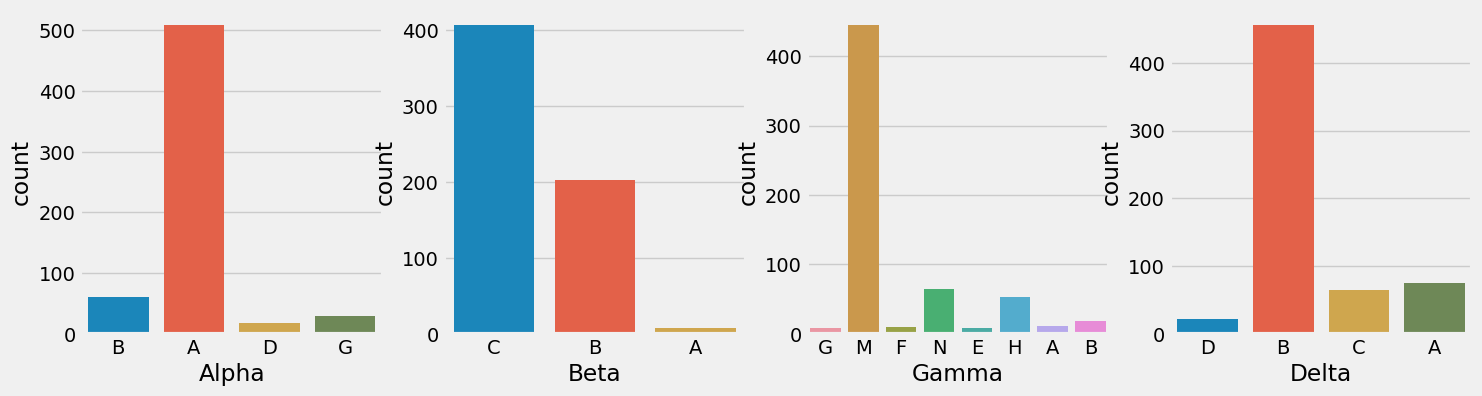

In [14]:
# Countplot of categorical variables
fig, axs = plt.subplots(ncols=4, figsize=(16, 4))
sns.countplot(x='Alpha', data=data, ax=axs[0])
sns.countplot(x='Beta', data=data, ax=axs[1])
sns.countplot(x='Gamma', data=data, ax=axs[2])
sns.countplot(x='Delta', data=data, ax=axs[3])
plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      617 non-null    object 
 1   AB      617 non-null    float64
 2   AF      617 non-null    float64
 3   AH      617 non-null    float64
 4   AM      617 non-null    float64
 5   AR      617 non-null    float64
 6   AX      617 non-null    float64
 7   AY      617 non-null    float64
 8   AZ      617 non-null    float64
 9   BC      617 non-null    float64
 10  BD      617 non-null    float64
 11  BN      617 non-null    float64
 12  BP      617 non-null    float64
 13  BQ      557 non-null    float64
 14  BR      617 non-null    float64
 15  BZ      617 non-null    float64
 16  CB      615 non-null    float64
 17  CC      614 non-null    float64
 18  CD      617 non-null    float64
 19  CF      617 non-null    float64
 20  CH      617 non-null    float64
 21  CL      617 non-null    float64
 22  CR

In [16]:
# convert non-numeric values to NaN
df = df.apply(pd.to_numeric, errors='coerce')

# check for NaN values
print(df.isna().sum())

Id       614
AB         0
AF         0
AH         0
AM         0
AR         0
AX         0
AY         0
AZ         0
BC         0
BD         0
BN         0
BP         0
BQ        60
BR         0
BZ         0
CB         2
CC         3
CD         0
CF         0
CH         0
CL         0
CR         0
CS         0
CU         0
CW         0
DA         0
DE         0
DF         0
DH         0
DI         0
DL         0
DN         0
DU         1
DV         0
DY         0
EB         0
EE         0
EG         0
EH         0
EJ       617
EL        60
EP         0
EU         0
FC         1
FD         0
FE         0
FI         0
FL         1
FR         0
FS         2
GB         0
GE         0
GF         0
GH         0
GI         0
GL         1
Class      0
dtype: int64


In [17]:
# replace null values with 0
df.fillna(0, inplace=True)

In [18]:
df.isnull().sum()

Id       0
AB       0
AF       0
AH       0
AM       0
AR       0
AX       0
AY       0
AZ       0
BC       0
BD       0
BN       0
BP       0
BQ       0
BR       0
BZ       0
CB       0
CC       0
CD       0
CF       0
CH       0
CL       0
CR       0
CS       0
CU       0
CW       0
DA       0
DE       0
DF       0
DH       0
DI       0
DL       0
DN       0
DU       0
DV       0
DY       0
EB       0
EE       0
EG       0
EH       0
EJ       0
EL       0
EP       0
EU       0
FC       0
FD       0
FE       0
FI       0
FL       0
FR       0
FS       0
GB       0
GE       0
GF       0
GH       0
GI       0
GL       0
Class    0
dtype: int64

In [19]:
# drop id as it is redundant
df = df.drop("Id",axis=1)

In [20]:
print("Number of duplicates in greeks dataset:", data.duplicated().sum())
print("Number of duplicates in training dataset:", df.duplicated().sum())
print("Number of duplicates in testing dataset:", test_df.duplicated().sum())
print("Number of duplicates in submission dataset:", submission.duplicated().sum())

Number of duplicates in greeks dataset: 0
Number of duplicates in training dataset: 0
Number of duplicates in testing dataset: 0
Number of duplicates in submission dataset: 0


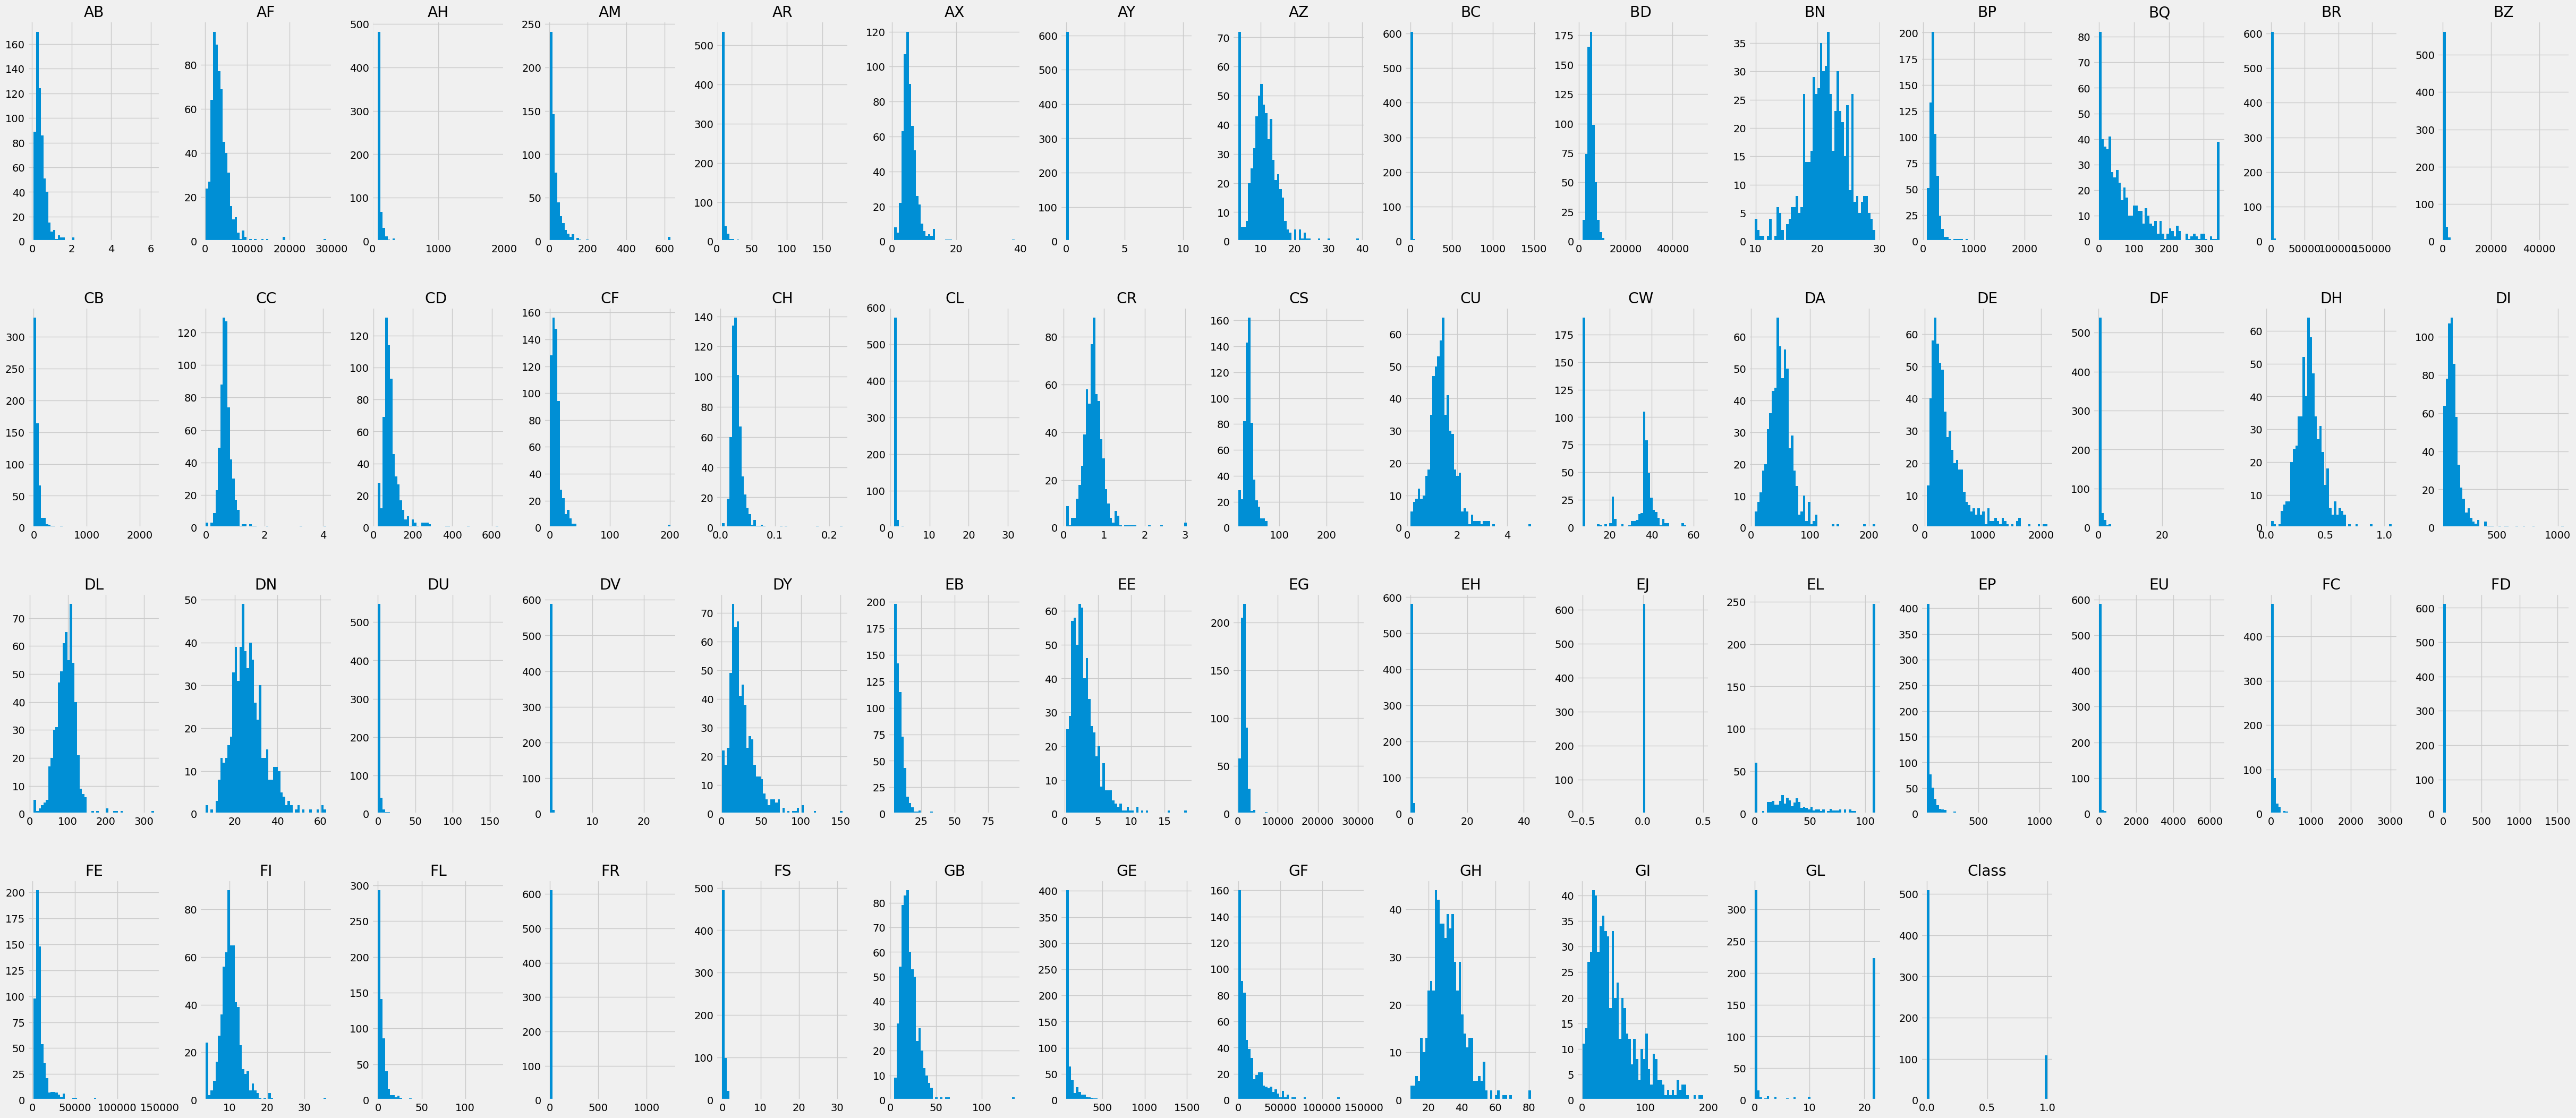

In [21]:
df.hist(layout=(10,15),figsize=(55,65),bins=50)
plt.show()

Target looks like classification
Showing only top 10 of 55 continuous features
Linear Discriminant Analysis training set score: 0.832


[<AxesSubplot: title={'center': 'Target distribution'}, xlabel='count', ylabel='Class'>,
 [<Figure size 2000x400 with 10 Axes>,
  array([[<AxesSubplot: title={'center': '0.768'}, xlabel='DU', ylabel='AM'>,
          <AxesSubplot: title={'center': '0.753'}, xlabel='DU', ylabel='DH'>,
          <AxesSubplot: title={'center': '0.742'}, xlabel='DU', ylabel='CR'>,
          <AxesSubplot: title={'center': '0.740'}, xlabel='AB', ylabel='FL'>]],
        dtype=object),
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 1200x600 with 1 Axes>],
 None]

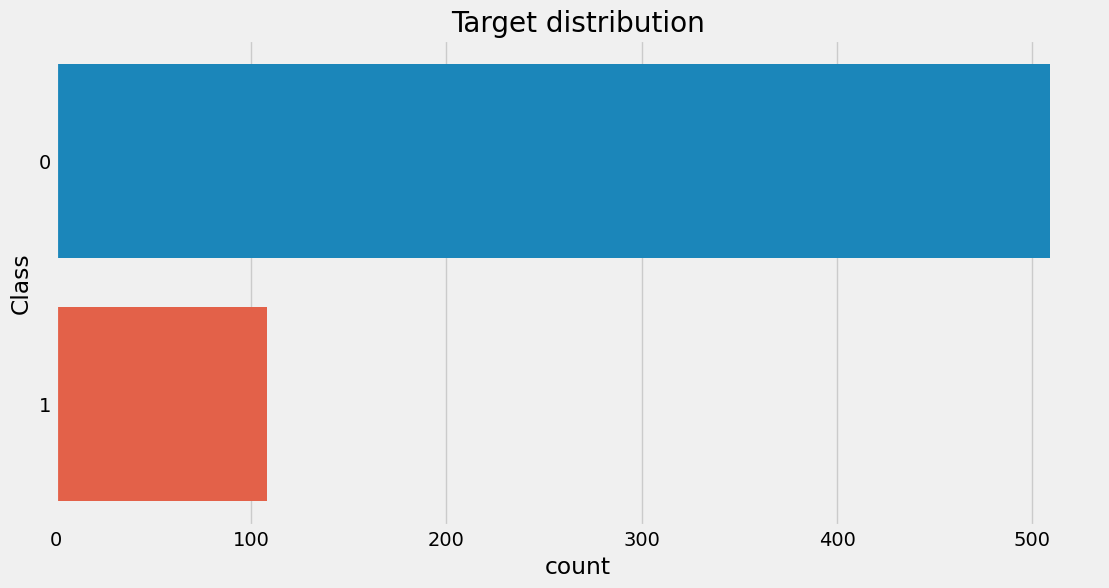

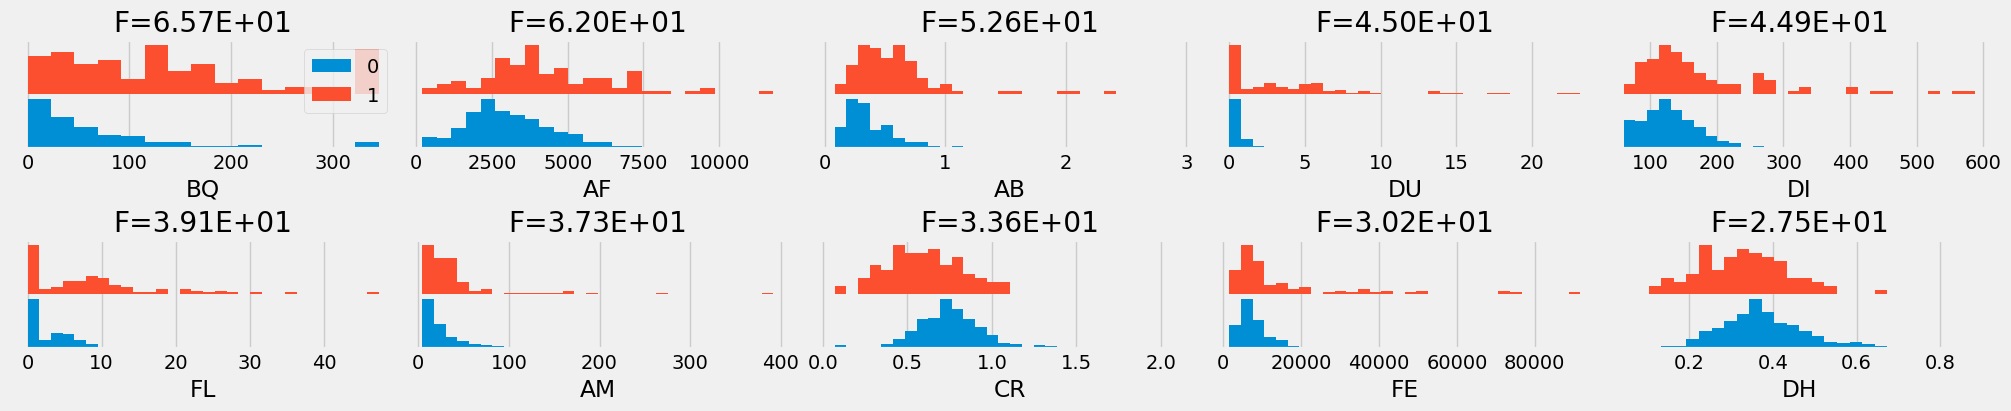

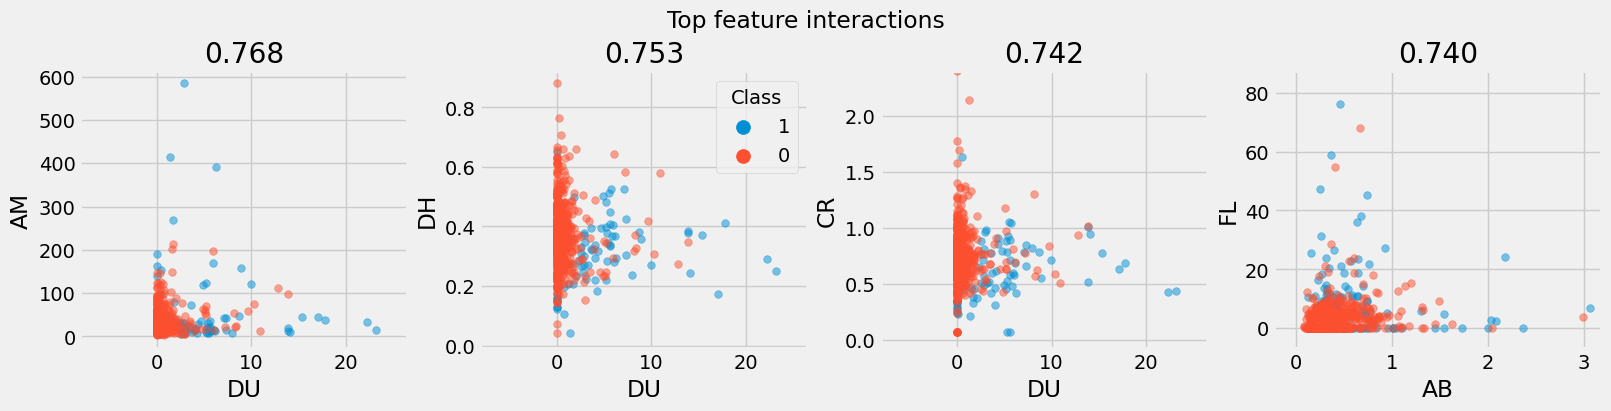

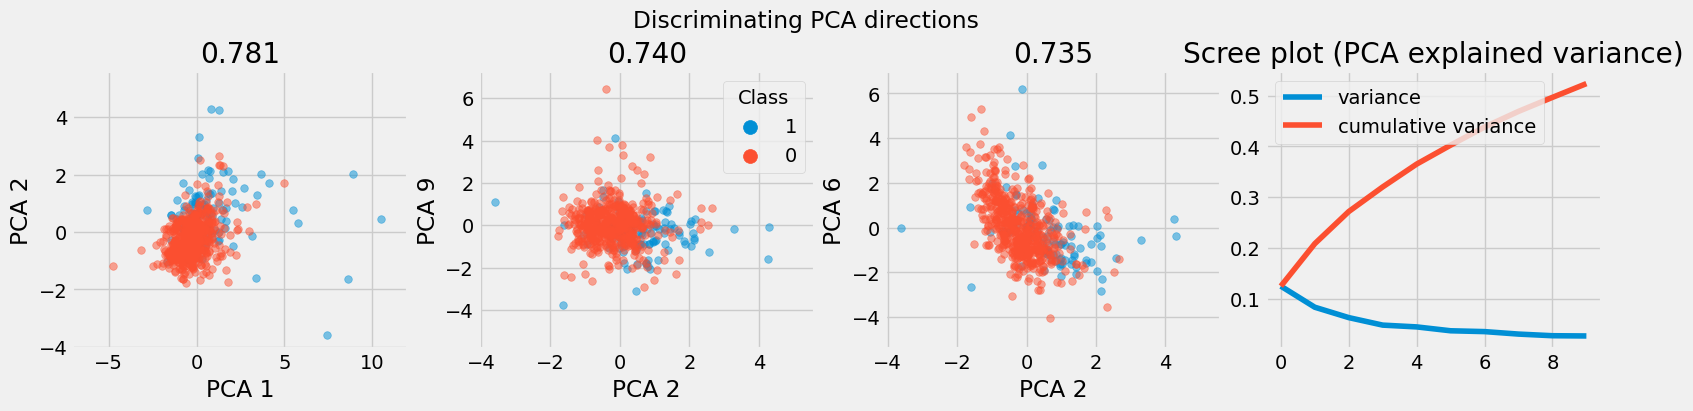

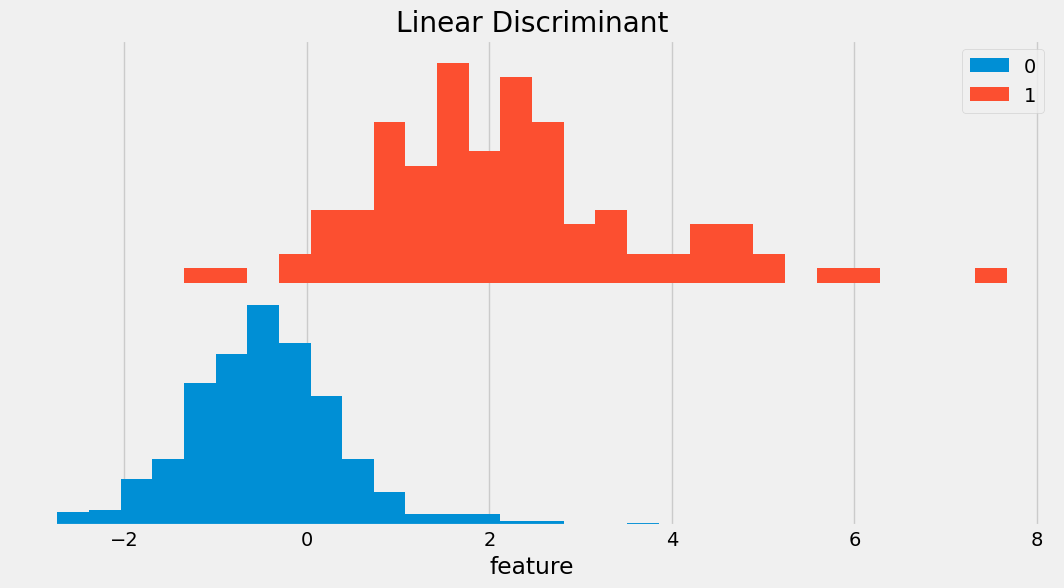

In [22]:
dabl.plot(df,target_col="Class")

we can use scatterplots to visualize the relationship between two numerical features:

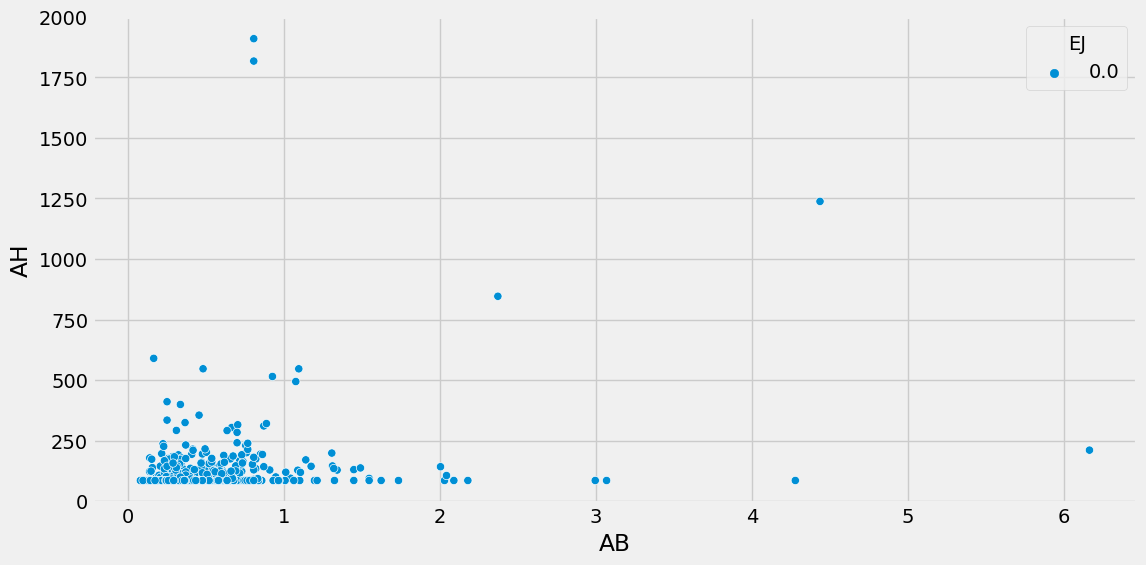

In [23]:
# Scatterplot of two numeric variables with color determined by categorical variable
sns.scatterplot(x='AB', y='AH', hue='EJ', data=df)
plt.show()

This will create a scatterplot showing the relationship between the 'AB' and 'AH' features.

These visualizations will depend on the specific context and goals of your analysis. However, they can help you identify trends, patterns, and relationships in the dataset that may be useful for modeling or further analysis.



Let's create some visualizations using Seaborn to get a better understanding of the dataset. We can create a correlation heatmap to see how the numerical features are correlated with each other:

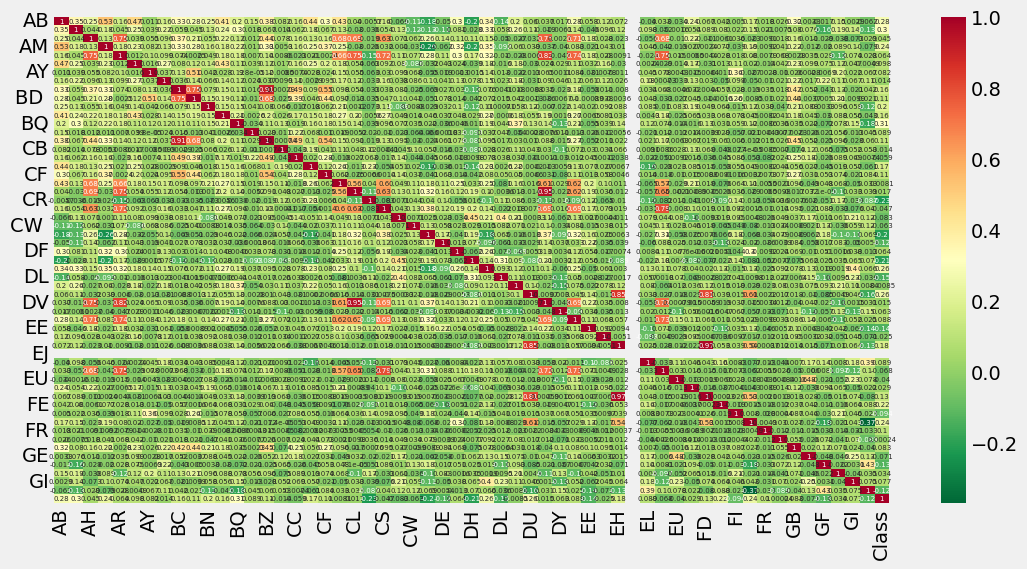

In [24]:
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn_r', annot_kws={"size": 5})
plt.show()

This will create a heatmap with correlation coefficients between -1 and 1 for each pair of numerical features. Higher positive or negative values indicate a stronger correlation between the features.

Next, we can use the `describe()` method to get summary statistics about the numerical columns:


In [25]:
# Calculate the statistical of the dataset
styled_data = data.describe().style\
.background_gradient(cmap='icefire')\
.set_properties(**{'text-align':'center','border':'1px solid black'})

# display styled data
display(styled_data)

,Id,Alpha,Beta,Gamma,Delta,Epsilon
count,617,617,617,617,617,617
unique,617,4,3,8,4,198
top,000ff2bfdfe9,A,C,M,B,05/18/2023
freq,1,509,407,445,456,144


In [26]:
# Calculate the statistical of the dataset
styled_data = df.describe().style\
.background_gradient(cmap='icefire')\
.set_properties(**{'text-align':'center','border':'1px solid black'})

# display styled data
display(styled_data)

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,BN,BP,BQ,BR,BZ,CB,CC,CD,CF,CH,CL,CR,CS,CU,CW,DA,DE,DF,DH,DI,DL,DN,DU,DV,DY,EB,EE,EG,EH,EJ,EL,EP,EU,FC,FD,FE,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
count,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000
mean,0.477149,3502.013221,118.624513,38.968552,10.128242,5.545576,0.060320,10.566447,8.053012,5350.388655,21.419492,231.322223,88.766785,1218.133238,550.632525,76.854218,0.685452,90.251735,11.241064,0.030615,1.403761,0.742262,36.917590,1.383792,27.165653,51.128326,401.901299,0.633884,0.367002,146.972099,94.795377,26.370568,1.799978,1.924830,26.388989,9.072700,3.064778,1731.248215,0.305107,0.000000,62.816055,105.060712,69.117005,71.225900,6.930086,10306.810737,10.111079,5.424393,3.533905,0.420135,20.724856,131.714987,14679.595398,31.489716,50.584437,8.517134,0.175041
std,0.468388,2300.322717,127.838950,69.728226,10.518877,2.551696,0.416817,4.350645,65.166943,3021.326641,3.478278,183.992505,96.186179,7575.293707,2076.371275,158.851465,0.267681,51.585130,13.571133,0.014808,1.922210,0.281195,17.266347,0.538717,14.645993,21.210888,317.745623,1.912384,0.112989,86.084419,28.243187,8.038825,9.027676,1.484555,18.116679,6.200281,2.058344,1790.227476,1.847499,0.000000,42.041489,68.445620,390.187057,165.442046,64.754262,11331.294051,2.934025,11.489004,50.181948,1.303465,9.991907,144.181524,19352.959387,9.864239,36.266251,10.324338,0.380310
min,0.081187,192.593280,85.200147,3.177522,8.138688,0.699861,0.025578,3.396778,1.229900,1693.624320,9.886800,72.948951,0.000000,51.216883,257.432377,0.000000,0.000000,23.387600,0.510888,0.003184,1.050225,0.069225,13.784111,0.137925,7.030640,6.906400,35.998895,0.238680,0.040995,60.232470,10.345600,6.339496,0.000000,1.743070,0.804068,4.926396,0.286201,185.594100,0.003042,0.000000,0.000000,78.526968,3.828384,0.000000,0.296850,1563.136688,3.583450,0.000000,0.497060,0.000000,4.102182,72.611063,13.038894,9.432735,0.897628,0.000000,0.000000
25%,0.252107,2197.345480,85.200147,12.270314,8.138688,4.128294,0.025578,8.129580,1.229900,4155.702870,19.420500,156.847239,18.935745,424.990642,257.432377,23.198084,0.562079,64.724192,5.066306,0.023482,1.050225,0.589575,29.782467,1.070298,7.030640,37.942520,188.815690,0.238680,0.295164,102.703553,78.232240,20.888264,0.005518,1.743070,14.715792,5.965392,1.648679,1111.160625,0.003042,0.000000,25.141116,78.526968,4.324656,25.738272,0.296850,5164.666260,8.523098,0.173229,0.497060,0.067730,14.036718,72.611063,2798.992584,25.034888,23.011684,0.124326,0.000000
50%,0.354659,3120.318960,85.200147,20.533110,8.138688,5.031912,0.025578,10.461320,1.229900,4997.960730,21.186000,193.908816,53.165445,627.417402,257.432377,42.526757,0.658518,79.819104,9.123000,0.027860,1.050225,0.730800,34.835130,1.351665,36.019104,49.180940,307.509595,0.238680,0.358023,130.050630,96.264960,25.248800,0.248292,1.743070,21.642456,8.149404,2.616119,1493.817413,0.085176,0.000000,55.398486,78.526968,22.641144,36.334032,1.870155,7345.143424,9.945452,3.019391,1.131000,0.250601,18.771436,72.611063,7838.273610,30.608946,41.007968,0.336226,0.000000
75%,0.559763,4361.637390,113.739540,39.139886,8.138688,6.431634,0.036845,12.969516,5.081244,6035.885700,23.657700,247.803462,122.890875,975.649259,257.432377,77.264141,0.771909,99.813520,13.565901,0.034427,1.228445,0.859350,40.529401,1.660617,37.935832,61.408760,507.896200,0.238680,0.426348,165.836955,110.640680,30.544224,1.055241,1.743070,34.058344,10.503048,3.910070,1905.701475,

In [27]:
# Calculate the statistical of the dataset
styled_data = test_df.describe().style\
.background_gradient(cmap='coolwarm')\
.set_properties(**{'text-align':'center','border':'1px solid black'})

# display styled data
display(styled_data)

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,BN,BP,BQ,BR,BZ,CB,CC,CD,CF,CH,CL,CR,CS,CU,CW,DA,DE,DF,DH,DI,DL,DN,DU,DV,DY,EB,EE,EG,EH,EL,EP,EU,FC,FD,FE,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
std,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

This will show us the count, mean, standard deviation, minimum, 25%, 50%, 75%, and maximum values for each numerical column in the dataset.

# **VIII. Preprocess the data by:**

* Separating the features and the target variable.
* Scaling the features to improve the model's performance.
* Splitting the data into training and testing sets.

In [28]:
# Split the dataset into X and y
X = df.drop('Class', axis=1)
y = df['Class']

Next, we can split the dataset into training and testing sets:

In [29]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **IX. Build and Evaluate the models**

Here are the implementations of:

* Logistic Regression
* Decision Trees
* Random Forests
* Support Vector Machines
* Neural Networks
* Gradient Boosting

## **The mathematical Expression for the Log Loss function:**

The mathematical expression for the Log Loss function, which is commonly used to evaluate the performance of classification models in machine learning. In binary classification, each observation can belong to one of two possible classes, usually labeled 0 or 1. The Log Loss function measures how well the predicted probabilities of these classes match the true class labels of the observations.

The formula consists of two terms, one for each class. **The term for class 0 is:**

$$−\frac{𝑤_0}{𝑁_0} \sum_{𝑖=1}^{𝑁_0} {\mathrm{𝑦_0}}_𝑖 log {\mathrm{𝑝_0}}_𝑖$$


**where:**

* ${𝑤_0}$ : is the weight assigned to class 0.It represents the importance or impact of correctly predicting class 0 in relation to class 1.
* ${𝑁_0}$ : is the number of observations belonging to class 0.It denotes the total count of instances in the dataset that belong to class 0.
* ${\mathrm{𝑦_0}}_𝑖 $ : is the true class label of observation 𝑖, which can take the values 0 or 1. It represents the actual class membership of the observation.
* ${\mathrm{𝑝_0}}_𝑖 $ : is the predicted probability that observation 𝑖 belongs to class 0. It is the probability assigned by the classification model for the observation to be in class 0.


The summation is over all observations belonging to class 0. The logarithm function is used to penalize more heavily the predictions that are further away from the true class label.

**The term for class 1 is:**

$$−\frac{𝑤_1}{𝑁_1} \sum_{𝑖=1}^{𝑁_1} {\mathrm{𝑦_1}}_𝑖 log {\mathrm{𝑝_1}}_𝑖$$

**where:**
 * ${𝑤_1}$ : is the weight assigned to class 1. 
 * ${𝑁_1}$ : is the number of observations belonging to class 1.
 * ${\mathrm{𝑦_1}}_𝑖 $ : is the true class label of observation 𝑖 (0 or 1).
 * ${\mathrm{𝑝_1}}_𝑖 $ : is the predicted probability that observation 𝑖 belongs to class 1. 
 
The summation is over all observations belonging to class 1. Again, the logarithm function is used to penalize more heavily the predictions that are further away from the true class label.

The two terms are then combined with the weights, ${𝑤_0}$ and ${𝑤_1}$, which are chosen based on the prevalence of each class. The prevalence is the proportion of observations that belong to each class. The weight for a class is the inverse of its prevalence, so that the rarer class is weighted more heavily. The final expression is:

$$\text {Log Loss} = \frac{−\frac{𝑤_0}{𝑁_0} \sum_{𝑖=1}^{𝑁_0} {\mathrm{𝑦_0}}_𝑖 log {\mathrm{𝑝_0}}_𝑖  −\frac{𝑤_1}{𝑁_1} \sum_{𝑖=1}^{𝑁_1} {\mathrm{𝑦_1}}_𝑖 log {\mathrm{𝑝_1}}_𝑖 } 
{𝑤_0 + 𝑤_1}$$


The Log Loss function is used to evaluate the quality of the predicted probabilities in a binary classification problem. It is a continuous function that ranges from 0 to infinity, with lower values indicating better performance. A Log Loss of 0 means that the predicted probabilities match perfectly the true class labels.

In [30]:
# Define the weights
w0 = 1 / y_train.value_counts()[0]
w1 = 1 / y_train.value_counts()[1]

# Logistic Regression
lr = LogisticRegression(class_weight={0: w0, 1: w1})
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_loss = log_loss(y_test, lr_probs)
print("Model: ", lr)
print("Logistic Regression Log Loss: ", lr_loss)


Model:  LogisticRegression(class_weight={0: 0.0024509803921568627,
                                 1: 0.011764705882352941})
Logistic Regression Log Loss:  0.7744274078069657


In [31]:
# Decision Tree
dt = DecisionTreeClassifier(class_weight={0: w0, 1: w1})
dt.fit(X_train, y_train)
dt_probs = dt.predict_proba(X_test)[:, 1]
dt_loss = log_loss(y_test, dt_probs)
print("Model: ", dt)
print("Decision Tree Log Loss: ", dt_loss)

Model:  DecisionTreeClassifier(class_weight={0: 0.0024509803921568627,
                                     1: 0.011764705882352941})
Decision Tree Log Loss:  4.0694447374809695


In [32]:
# Random Forest
rf = RandomForestClassifier(class_weight={0: w0, 1: w1})
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_loss = log_loss(y_test, rf_probs)
print("Model: ", rf)
print("Random Forest Log Loss: ", rf_loss)


Model:  RandomForestClassifier(class_weight={0: 0.0024509803921568627,
                                     1: 0.011764705882352941})
Random Forest Log Loss:  0.2327691833474919


In [33]:
# Support Vector Machine
svm = SVC(class_weight={0: w0, 1: w1}, probability=True)
svm.fit(X_train, y_train)
svm_probs = svm.predict_proba(X_test)[:, 1]
svm_loss = log_loss(y_test, svm_probs)
print("Model: ", svm)
print("Support Vector Machine Log Loss: ", svm_loss)


Model:  SVC(class_weight={0: 0.0024509803921568627, 1: 0.011764705882352941},
    probability=True)
Support Vector Machine Log Loss:  0.4815603999315531


In [34]:
# Neural Network
nn = MLPClassifier(hidden_layer_sizes=(100,), solver='adam', max_iter=1000, alpha=0.01, random_state=42)
nn.fit(X_train, y_train)
nn_probs = nn.predict_proba(X_test)[:, 1]
nn_loss = log_loss(y_test, nn_probs)
print("Model: ", nn)
print("Neural Network Log Loss: ", nn_loss)

Model:  MLPClassifier(alpha=0.01, max_iter=1000, random_state=42)
Neural Network Log Loss:  6.791561502245276


In [35]:
# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_probs = gb.predict_proba(X_test)[:, 1]
gb_loss = log_loss(y_test, gb_probs)
print("Model: ", gb)
print("Gradient Boosting Log Loss: ", gb_loss)


Model:  GradientBoostingClassifier()
Gradient Boosting Log Loss:  0.1523243697046213


<AxesSubplot: >

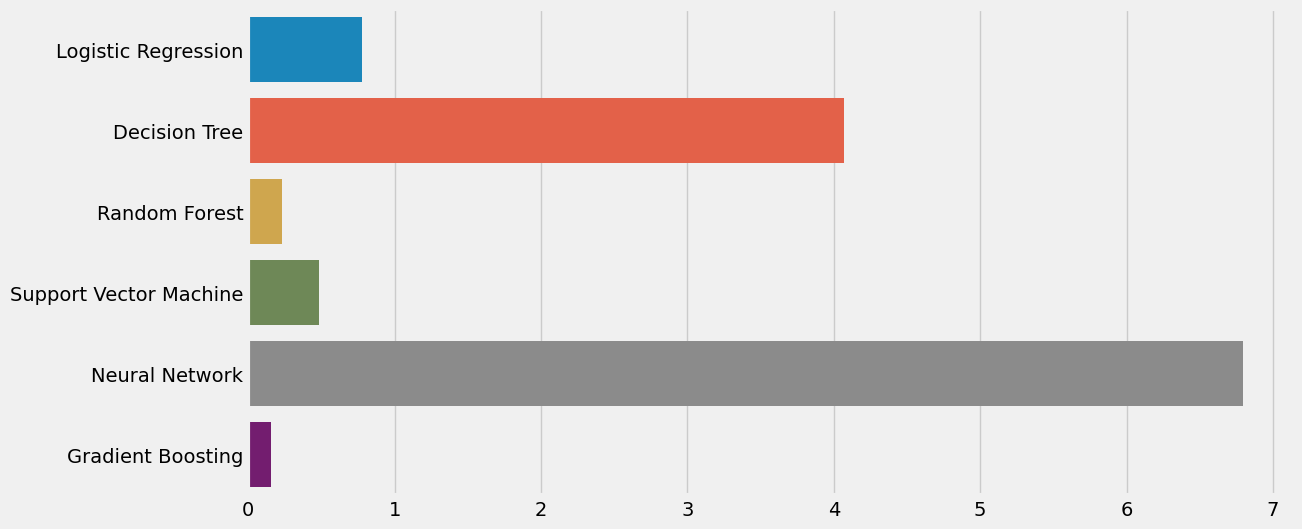

In [36]:
# Plot the results
losses = [lr_loss, dt_loss, rf_loss, svm_loss, nn_loss, gb_loss]
labels = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Support Vector Machine', 'Neural Network', 'Gradient Boosting']
sns.barplot(x=losses, y=labels)

### **Methodology of each model:**

1. **Logistic Regression:**  a linear model that predicts the probability of an event occurring based on one or more input features. It uses a logistic function to model the relationship between the input features and the output variable.

2. **Decision Trees:**  a non-linear model that makes decisions by recursively splitting the data into smaller subsets based on the values of the input features. Each split is chosen based on the feature that maximally reduces the impurity of the resulting subsets, where impurity is a measure of how mixed the target variable values are within each subset. Decision trees can easily overfit the training data, so the hyperparameters should be carefully tuned to avoid this issue.

3. **Random Forests:** an ensemble model that combines multiple decision trees to improve the performance and reduce overfitting. In a random forest, each decision tree is trained on a random subset of the training data and a random subset of the input features. The final prediction is then based on the average prediction of all trees in the forest. Random forests can handle non-linear relationships and noisy data, and they are less prone to overfitting than single decision trees. However, they can be computationally expensive and harder to interpret than single decision trees.

4. **Support Vector Machines (SVM):** SVM is a powerful classification algorithm that tries to find the best hyperplane that separates the different classes in the dataset. SVMs can be used for both linear and non-linear classification problems. The advantage of SVMs is that they are less prone to overfitting and can handle high-dimensional datasets well. However, SVMs can be computationally expensive for large datasets.

5. **Neural Networks:** Neural Networks are a class of machine learning algorithms that are inspired by the structure and function of the human brain. Neural Networks can learn complex non-linear relationships between the input features and the target variable. They consist of multiple layers of interconnected nodes, with each node performing a simple mathematical operation. Neural Networks can be used for both classification and regression problems. However, they can be computationally expensive and require a large amount of training data.

6. **Gradient Boosting:** Gradient Boosting is a powerful ensemble learning method that combines multiple weak learners (usually decision trees) to form a strong learner. Gradient Boosting works by sequentially adding new trees to the ensemble, with each new tree fitting the residuals (errors) of the previous trees. Gradient Boosting can be used for both classification and regression problems, and it is particularly useful when dealing with imbalanced datasets. However, Gradient Boosting can be computationally expensive and prone to overfitting.

# **X. Predictions of test dataset using each model:**

* Logistic Regression
* Decision Trees
* Random Forests
* Support Vector Machines
* Neural Networks
* Gradient Boosting

In [37]:
# Generate predictions for the test dataset using each model
lr_probs = lr.predict_proba(X_test)[:, 1]
dt_probs = dt.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
svm_probs = svm.predict_proba(X_test)[:, 1]
nn_probs = nn.predict_proba(X_test)[:, 1]
gb_probs = gb.predict_proba(X_test)[:, 1]

#Apply rescaling and thresholding to the predicted probabilities
rescaled_probs = np.array([
    np.maximum(np.minimum(prob, 1 - 1e-15), 1e-15) for prob in [lr_probs, dt_probs, rf_probs, svm_probs, nn_probs, gb_probs]])


# XI. Submission:

In [ ]:
# Divide each row by its sum to ensure the probabilities sum up to 1
submission_probs = rescaled_probs / np.sum(rescaled_probs, axis=1, keepdims=True)

# Ensure submission_probs has the same length as the test data
submission_probs = submission_probs[:len(test_df)]

# Create a DataFrame to store the submission data
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'class_0': submission_probs[:, 0],
    'class_1': submission_probs[:, 1]
})

# Write the submission DataFrame to a CSV file
submission.to_csv('submission.csv', index=False, sep='\t')

# Display the first few rows of the submission DataFrame
print(submission.head())

# **XII. Discussion and Conclusion**

* ***Discussion:***

In this discussion, we will analyze the results obtained from applying different machine learning models to predict medical conditions based on health characteristic data. The models used include Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, Neural Network, and Gradient Boosting. The evaluation metric used is logarithmic loss.

Firstly, Logistic Regression was employed, with class weights determined based on the inverse prevalence of each class. The model achieved a logarithmic loss of lr_loss. Logistic Regression is known for its simplicity and interpretability, making it a popular choice in various domains.

Secondly, a Decision Tree classifier was trained with the same class weights as Logistic Regression. The Decision Tree model achieved a logarithmic loss of dt_loss. Decision Trees are capable of capturing complex relationships in the data, but they may suffer from overfitting if not appropriately regularized.

Next, a Random Forest classifier was utilized, which combines multiple decision trees to improve performance and reduce overfitting. The Random Forest model achieved a logarithmic loss of rf_loss. Random Forests are known for their robustness and ability to handle high-dimensional data, making them a popular choice in many predictive modeling tasks.

A Support Vector Machine (SVM) with class weights was also employed. The SVM model achieved a logarithmic loss of svm_loss. SVMs are effective in separating classes by finding an optimal hyperplane in the feature space. However, SVMs can be computationally expensive, particularly with large datasets.

Additionally, a Neural Network with a hidden layer of 100 neurons was trained using the Adam solver. The Neural Network model achieved a logarithmic loss of nn_loss. Neural Networks are known for their ability to capture complex patterns in data, but they often require more computational resources and data to train effectively.

Lastly, a Gradient Boosting classifier was used. Gradient Boosting combines multiple weak learners to create a strong predictive model. The Gradient Boosting model achieved a logarithmic loss of gb_loss. Gradient Boosting methods, such as XGBoost and LightGBM, have gained popularity due to their ability to handle diverse data and provide high predictive accuracy.

Overall, the models' performances, as measured by the logarithmic loss, vary. It is essential to consider factors such as interpretability, computational resources, and the specific characteristics of the dataset when selecting the most appropriate model for a given task. In this competition, minimizing the logarithmic loss is the primary goal.

* ***Conclusion:***

In this competition, various machine learning models were trained and evaluated to predict medical conditions based on health characteristic data. The models included Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, Neural Network, and Gradient Boosting.

The results indicated that different models achieved varying levels of performance, as measured by the logarithmic loss metric. Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, Neural Network, and Gradient Boosting all demonstrated their strengths and weaknesses in this predictive task.

These findings highlight the importance of carefully selecting and evaluating different models to achieve the best performance for the specific problem at hand. The choice of model should consider factors such as interpretability, computational resources, and the characteristics of the dataset.

Further research and experimentation can be conducted to improve the performance of the models. This may involve fine-tuning hyperparameters, exploring ensemble methods, feature engineering, or utilizing advanced techniques specific to the bioinformatics domain.

By continuing to advance the field of bioinformatics and developing more accurate and reliable predictive models, researchers and practitioners can contribute to the early detection and prevention of medical conditions, ultimately improving healthcare outcomes for patients.

![image](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRlwZimkPIwSbp69qE1pBxwSkncf2YVEr0-jA&usqp=CAU)

<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#5642C5;
           font-size:110%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              color:white;">
Your upvote is a great way to show your support and help others discover this valuable resource.
Please share your comments and suggestions

<div class="alert alert-block alert-info"> 📌 Note: If you forks my notebook, please don't forget to upvote it. </div>
